[lr=0.1] Epoch 1: Loss=0.4419, Accuracy=91.92%
[lr=0.1] Epoch 2: Loss=0.2259, Accuracy=94.79%
[lr=0.1] Epoch 3: Loss=0.1694, Accuracy=94.82%
[lr=0.1] Epoch 4: Loss=0.1350, Accuracy=96.44%
[lr=0.1] Epoch 5: Loss=0.1131, Accuracy=96.75%
[lr=0.01] Epoch 1: Loss=1.2538, Accuracy=86.17%
[lr=0.01] Epoch 2: Loss=0.4980, Accuracy=89.37%
[lr=0.01] Epoch 3: Loss=0.3942, Accuracy=90.41%
[lr=0.01] Epoch 4: Loss=0.3532, Accuracy=90.84%
[lr=0.01] Epoch 5: Loss=0.3284, Accuracy=91.44%
[lr=0.001] Epoch 1: Loss=2.2075, Accuracy=56.16%
[lr=0.001] Epoch 2: Loss=1.9845, Accuracy=68.76%
[lr=0.001] Epoch 3: Loss=1.6945, Accuracy=75.48%
[lr=0.001] Epoch 4: Loss=1.3928, Accuracy=78.96%
[lr=0.001] Epoch 5: Loss=1.1433, Accuracy=81.64%


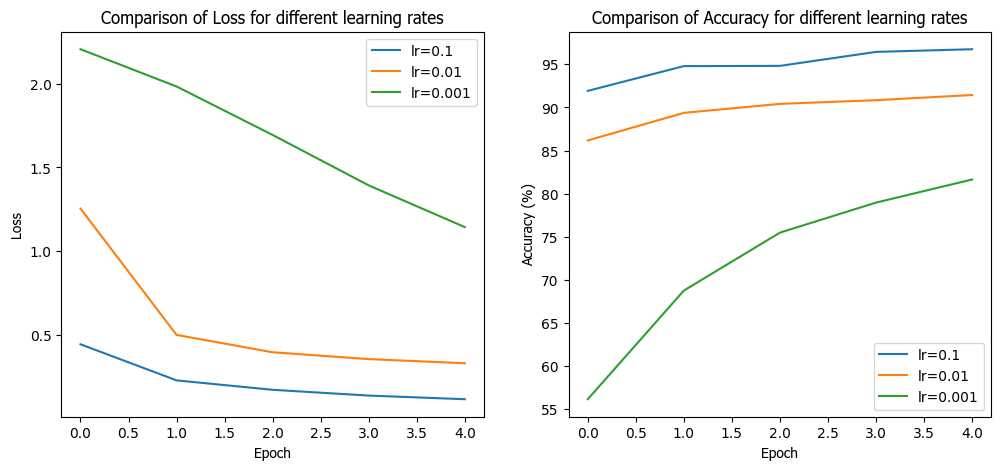

In [4]:
# ---------------------------------------------
# 📌 کتابخانه‌های مورد نیاز
# torch = کتابخانه‌ی PyTorch برای ساخت شبکه عصبی
# torchvision = شامل دیتاست‌های آماده مثل MNIST
# matplotlib = برای رسم نمودار و مقایسه‌ی نتایج
# ---------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ---------------------------------------------
# 📌 آماده‌سازی دیتاست MNIST
# - با transform فقط تصاویر را به Tensor تبدیل می‌کنیم
# - batch_size = 64 یعنی در هر بار پردازش 64 تصویر وارد شبکه می‌شود
# ---------------------------------------------
transform = transforms.ToTensor()

trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                      download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False,
                                     download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1000, shuffle=False)

# ---------------------------------------------
# 📌 تعریف مدل شبکه عصبی ساده (MLP)
# - لایه اول: 784 → 128
# - ReLU: فعال‌سازی غیرخطی
# - لایه خروجی: 128 → 10
# ---------------------------------------------
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)   # ورودی: تصویر MNIST (784 ویژگی) → لایه مخفی
        self.relu = nn.ReLU()              # تابع فعال‌سازی ReLU
        self.fc2 = nn.Linear(128, 10)      # خروجی: 10 کلاس (0 تا 9)

    def forward(self, x):
        # x: ورودی که به شکل (batch_size, 1, 28, 28) است
        x = x.view(-1, 28*28)   # تصویر تخت می‌شود → بردار 784 تایی
        x = self.fc1(x)         # اعمال وزن و بایاس لایه اول
        x = self.relu(x)        # اعمال تابع فعال‌سازی
        x = self.fc2(x)         # خروجی لایه دوم (10 عدد)
        return x

# ---------------------------------------------
# 📌 تابع آموزش (train) و ارزیابی (test)
# - این تابع یک مدل، optimizer و lr خاص می‌گیرد
# - Loss و Accuracy در طول epochها ذخیره و برگردانده می‌شود
# ---------------------------------------------
def train_and_evaluate(lr, epochs=5):
    model = SimpleMLP()
    criterion = nn.CrossEntropyLoss()              # تابع خطا: CrossEntropy برای classification
    optimizer = optim.SGD(model.parameters(), lr=lr)   # بهینه‌ساز: SGD با نرخ یادگیری lr

    train_losses, test_accuracies = [], []

    for epoch in range(epochs):
        model.train()   # حالت آموزش
        running_loss = 0.0
        for images, labels in trainloader:
            optimizer.zero_grad()          # پاک کردن گرادیان‌ها از مرحله‌ی قبل
            outputs = model(images)        # 🔸 forward pass
            loss = criterion(outputs, labels)  # محاسبه خطا
            loss.backward()                # 🔸 backward pass (محاسبه گرادیان‌ها)
            optimizer.step()               # 🔸 بروزرسانی وزن‌ها بر اساس گرادیان و lr

            running_loss += loss.item()

        avg_loss = running_loss / len(trainloader)
        train_losses.append(avg_loss)

        # 🔸 ارزیابی روی داده‌ی تست
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():   # در تست نیاز به محاسبه گرادیان نداریم
            for images, labels in testloader:
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)

        print(f"[lr={lr}] Epoch {epoch+1}: Loss={avg_loss:.4f}, Accuracy={accuracy:.2f}%")

    return train_losses, test_accuracies

# ---------------------------------------------
# 📌 اجرای آزمایش با چند نرخ یادگیری مختلف
# ---------------------------------------------
lrs = [0.1, 0.01, 0.001]
results = {}

for lr in lrs:
    losses, accs = train_and_evaluate(lr, epochs=5)
    results[lr] = (losses, accs)

# ---------------------------------------------
# 📌 رسم نمودار مقایسه‌ای
# - منحنی Loss برای هر نرخ یادگیری
# - منحنی Accuracy برای هر نرخ یادگیری
# ---------------------------------------------
plt.figure(figsize=(12,5))

# نمودار Loss
plt.subplot(1,2,1)
for lr in lrs:
    plt.plot(results[lr][0], label=f"lr={lr}")
plt.title("Comparison of Loss for different learning rates" ,fontname="Tahoma")
plt.xlabel("Epoch", fontname="Tahoma")
plt.ylabel("Loss", fontname="Tahoma")
plt.legend()

# نمودار Accuracy
plt.subplot(1,2,2)
for lr in lrs:
    plt.plot(results[lr][1], label=f"lr={lr}")
plt.title("Comparison of Accuracy for different learning rates", fontname="Tahoma")
plt.xlabel("Epoch", fontname="Tahoma")
plt.ylabel("Accuracy (%)", fontname="Tahoma")
plt.legend()

plt.show()


[LR=0.1] Epoch 1/5 | Loss=0.4469 | Test Acc=91.61%
[LR=0.1] Epoch 2/5 | Loss=0.2301 | Test Acc=94.42%
[LR=0.1] Epoch 3/5 | Loss=0.1731 | Test Acc=95.60%
[LR=0.1] Epoch 4/5 | Loss=0.1383 | Test Acc=96.07%
[LR=0.1] Epoch 5/5 | Loss=0.1153 | Test Acc=96.05%
[LR=0.01] Epoch 1/5 | Loss=1.2624 | Test Acc=86.41%
[LR=0.01] Epoch 2/5 | Loss=0.4973 | Test Acc=89.14%
[LR=0.01] Epoch 3/5 | Loss=0.3934 | Test Acc=90.24%
[LR=0.01] Epoch 4/5 | Loss=0.3515 | Test Acc=90.83%
[LR=0.01] Epoch 5/5 | Loss=0.3260 | Test Acc=91.54%
[LR=0.001] Epoch 1/5 | Loss=2.2040 | Test Acc=54.88%
[LR=0.001] Epoch 2/5 | Loss=1.9736 | Test Acc=68.80%
[LR=0.001] Epoch 3/5 | Loss=1.6770 | Test Acc=74.76%
[LR=0.001] Epoch 4/5 | Loss=1.3733 | Test Acc=79.34%
[LR=0.001] Epoch 5/5 | Loss=1.1245 | Test Acc=81.91%


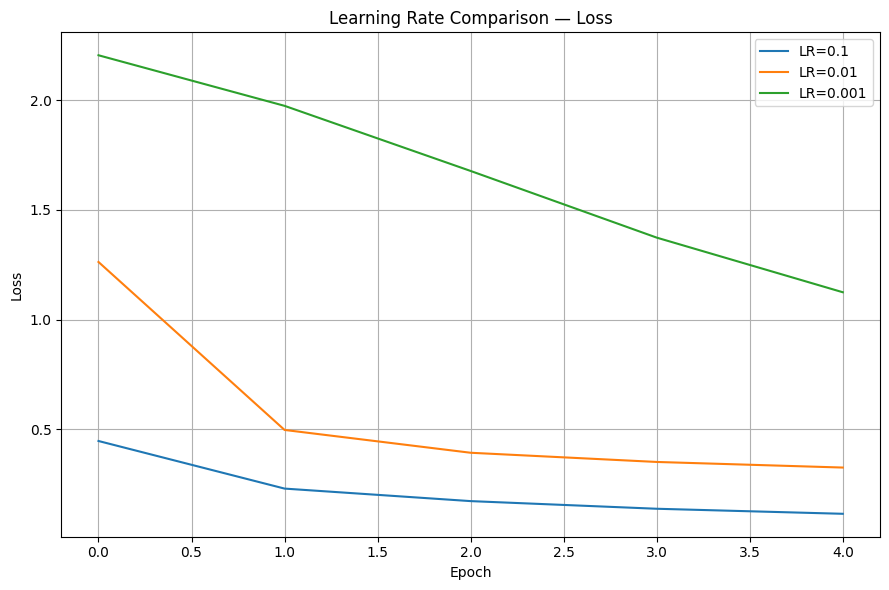

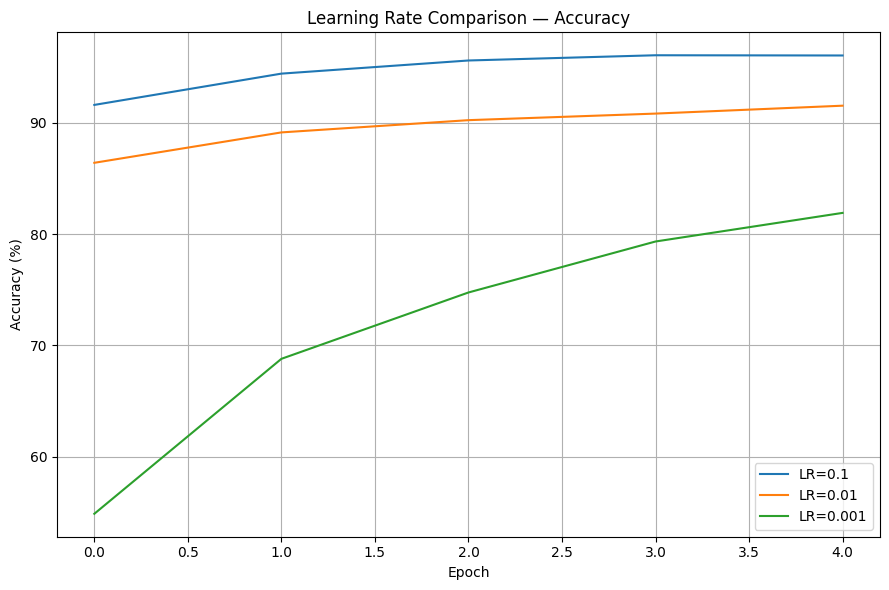

✅ تمام شد. دو فایل نمودار ذخیره شدند:
 - mnist_lr_loss.png
 - mnist_lr_acc.png


'\nراهنمای تفسیر نتایج:\n- LR خیلی بزرگ (مثلاً 0.1) ممکن است سریع شروع کند، اما اگر خیلی بزرگ باشد می\u200cتواند نوسانی/بی\u200cثبات یا حتی واگرا شود.\n- LR متوسط (0.01) معمولاً تعادل خوبی بین سرعت و پایداری دارد.\n- LR خیلی کوچک (0.001) پایدار است ولی ممکن است بسیار کند یاد بگیرد.\nپیشنهاد عملی: اول با 0.01 شروع کن؛ اگر training خیلی کند بود، کمی افزایش بده؛ اگر نمودار loss نوسانی شد یا acc گیر کرد، کمی کاهش بده.\n'

In [3]:
# -*- coding: utf-8 -*-
"""
آزمایش اثر نرخ یادگیری (Learning Rate) روی آموزش یک شبکه‌ی عصبی ساده (MLP) بر دیتاست واقعی MNIST
------------------------------------------------------------------------------------------------------
آنچه این کُد انجام می‌دهد:
1) دیتاست واقعی MNIST را از torchvision دانلود/لود می‌کند.
2) یک مدل MLP ساده تعریف می‌کند: ورودی 28x28 -> لایه مخفی 128 با ReLU -> خروجی 10 کلاس.
3) برای چند Learning Rate مختلف (خیلی کوچک، مناسب، خیلی بزرگ) با بهینه‌ساز SGD آموزش می‌دهد.
4) در هر epoch، میانگین Loss آموزش و دقت (Accuracy) روی تست را ثبت می‌کند.
5) دو نمودار رسم می‌کند: روند Loss و روند Accuracy برای هر نرخ یادگیری (همه روی یک نمودار برای مقایسه).

یادداشت‌ها:
- چون نمایش صحیح فارسی در Matplotlib بدون ابزارهای تکمیلی مشکل دارد، یک سوئیچ گذاشته شده:
  ENABLE_PERSIAN_TITLES را اگر True کنید و arabic_reshaper و python-bidi و یک فونت فارسی داشته باشید،
  عنوان‌ها و برچسب‌ها فارسی و درست نمایش داده می‌شوند. در غیر این‌صورت، عنوان‌ها انگلیسی هستند.
- توضیحات آموزشی (چرایی و چیستی) بالای هر بلاک/خط مهم آمده است.
"""

# -----------------------------
# 📌 تنظیمات عمومی و سوئیچ فارسی
# -----------------------------
ENABLE_PERSIAN_TITLES = False  # اگر کتابخانه‌های bidi/reshaper و فونت فارسی دارید، True کنید.

# -----------------------------
# 📌 وارد کردن کتابخانه‌ها
# torch: چارچوب یادگیری عمیق
# torchvision: دیتاست‌های آماده از جمله MNIST
# nn: ماژول ساخت لایه‌ها و توابع از دست
# optim: بهینه‌سازها (SGD و ...)
# transforms: پیش‌پردازش داده (تبدیل تصویر به Tensor)
# matplotlib: رسم نمودار برای مقایسه
# -----------------------------
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# اگر بخواهیم عنوان/برچسب فارسی را «واقعاً» درست نمایش دهیم، باید shaping و bidi را اعمال کنیم.
# در غیر این صورت، از متن‌های انگلیسی استفاده می‌کنیم تا وارونه/به‌هم‌ریخته نشوند.
if ENABLE_PERSIAN_TITLES:
    try:
        import arabic_reshaper
        from bidi.algorithm import get_display
        HAS_RTL = True
    except Exception:
        HAS_RTL = False
else:
    HAS_RTL = False

def fa(text):
    """اگر نمایش راست‌به‌چپ فعال و کتابخانه‌ها موجود باشد، متن فارسی را reshape+bidi می‌کند؛
    در غیر این‌صورت همان متن را برمی‌گرداند (یا در کل از نسخه انگلیسی استفاده می‌کنیم)."""
    if HAS_RTL:
        return get_display(arabic_reshaper.reshape(text))
    return text

# -----------------------------
# 📌 پیکربندی: دستگاه اجرا (GPU اگر در دسترس باشد)، batch size، تعداد epochها، لیست LRها
# چرا اینجا؟ چون پارامترهای آزمایش را شفاف در یک‌جا ببینیم.
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64          # اندازه‌ی بچ برای به‌روز کردن گرادیان‌ها — مقدار رایج و متعادل
num_epochs = 5           # برای MNIST همین مقدار کم هم کافی‌ست تا تفاوت LRها دیده شود
learning_rates = [0.1, 0.01, 0.001]  # بزرگ/متوسط/کوچک

# -----------------------------
# 📌 آماده‌سازی داده‌ی واقعی MNIST
# چرا ToTensor؟ تبدیل تصویر [0..255] به [0..1] و شکل (C,H,W) مورد نیاز PyTorch
# چرا shuffle؟ تا ترتیب داده‌ها باعث بایاس در یادگیری نشود.
# -----------------------------
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=0
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=1000, shuffle=False, num_workers=0
)

# -----------------------------
# 📌 تعریف مدل: یک شبکه‌ی پرسیپترون چندلایه‌ی ساده (MLP)
# چرا این معماری؟ ساده و سریع است ولی برای MNIST کافی‌ست تا اثر LR را ببینیم.
# forward چیست؟ مسیر محاسبات از ورودی تا خروجی برای به‌دست‌آوردن پیش‌بینی‌ها.
# -----------------------------
class SimpleMLP(nn.Module):
    def __init__(self):
        """
        در سازنده‌ی مدل، لایه‌ها را تعریف می‌کنیم:
        - fc1: لایه‌ی خطی از فضای 784-بُعدی (28x28 پیکسل) به 128 نورون
        - ReLU: غیرخطی‌سازی برای افزایش بیان‌پذیری مدل
        - fc2: لایه‌ی خروجی 10-بعدی (برای کلاس‌های 0 تا 9)
        """
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)  # وزن‌ها و بایاسِ لایه‌ی اول
        self.relu = nn.ReLU()               # تابع فعال‌ساز ReLU
        self.fc2 = nn.Linear(128, 10)       # وزن‌ها و بایاسِ لایه‌ی دوم (خروجی)

    def forward(self, x):
        """
        🔵 forward: این تابع «مسیر محاسبات» در فاز پیشرو را تعریف می‌کند.
        چرا لازم است؟ چون PyTorch براساس forward گراف محاسباتی را می‌سازد تا گرادیان‌ها را خودکار محاسبه کند.
        مراحل:
        1) ورودی x شکل (batch_size, 1, 28, 28) دارد؛ برای MLP باید آن را به بردار 784تایی «تخت» کنیم.
        2) اعمال لایه‌ی خطی اول (ضرب ماتریسی + بایاس)
        3) اعمال ReLU برای غیرخطی‌سازی
        4) اعمال لایه‌ی خطی دوم برای تولید logits (امتیاز هر کلاس)
        خروجی: logits با شکل (batch_size, 10). این خروجی هنوز Softmax نشده؛
        در تابع هزینه‌ی CrossEntropyLoss خود PyTorch softmax را به‌شکل درونی اعمال می‌کند.
        """
        x = x.view(-1, 28 * 28)  # 1) تخت کردن تصویر
        x = self.fc1(x)          # 2) لایه‌ی خطی اول
        x = self.relu(x)         # 3) ReLU
        x = self.fc2(x)          # 4) لایه‌ی خطی دوم (خروجی 10کلاسه)
        return x

# -----------------------------
# 📌 تابع کمکی: یک epoch آموزش
# چرا جداش کردیم؟ برای خوانایی و اینکه دقیقاً نقش هر مرحله معلوم باشد.
# مراحل داخل train_one_epoch:
# - model.train(): اطلاع به PyTorch که در حالت آموزش هستیم (مثلاً Dropout/BatchNorm متفاوت عمل می‌کنند).
# - برای هر بچ:
#     a) optimizer.zero_grad(): پاک‌کردن گرادیان‌های قبلی
#     b) forward: خروجی مدل روی ورودی‌های این بچ
#     c) loss = criterion(outputs, labels): محاسبه‌ی خطا
#     d) loss.backward(): بک‌پراپ — محاسبه‌ی گرادیان‌ها نسبت به پارامترها
#     e) optimizer.step(): بروزرسانی پارامترها با توجه به گرادیان‌ها و LR
# -----------------------------
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()           # a) پاک‌کردن گرادیان‌ها
        outputs = model(images)         # b) 🔵 forward
        loss = criterion(outputs, labels)  # c) محاسبه‌ی خطا
        loss.backward()                 # d) 🔴 backward (محاسبه گرادیان‌ها خودکار)
        optimizer.step()                # e) ✳️ بروزرسانی وزن‌ها براساس LR و گرادیان‌ها

        running_loss += loss.item()
    avg_loss = running_loss / len(loader)
    return avg_loss

# -----------------------------
# 📌 تابع کمکی: ارزیابی روی داده‌ی تست
# چرا no_grad؟ چون در فاز ارزیابی نیازی به ساخت گراف/گرادیان نداریم → سریع‌تر و کم‌مصرف‌تر.
# درست‌بودن پیش‌بینی‌ها: argmax روی logits بیشترین امتیاز کلاس را می‌دهد.
# -----------------------------
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)                # 🔵 forward (فقط پیش‌بینی)
            _, predicted = torch.max(outputs, 1)   # برچسب پیش‌بینی‌شده = ایندکس بیشترین لاجیت
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = 100.0 * correct / total
    return acc

# -----------------------------
# 📌 اجرای آزمایش برای هر Learning Rate
# چرا criterion=CrossEntropyLoss؟ چون برای classification چندکلاسه استاندارد است
# (و Softmax را درون خودش دارد).
# برای هر LR:
#   - یک مدل تازه می‌سازیم (تا اثر LR قبلی باقی نماند)
#   - بهینه‌ساز SGD با همان LR
#   - در num_epochs دوره: train + evaluate و ثبت لاگ‌ها
# -----------------------------
results = {}  # برای نگه‌داری تاریخچه‌ی loss و accuracy هر LR
for lr in learning_rates:
    model = SimpleMLP().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    train_losses = []
    test_accuracies = []

    for epoch in range(num_epochs):
        avg_loss = train_one_epoch(model, train_loader, criterion, optimizer)  # یک epoch کامل آموزش
        acc = evaluate(model, test_loader)                                     # سنجش دقت روی تست
        train_losses.append(avg_loss)
        test_accuracies.append(acc)
        print(f"[LR={lr}] Epoch {epoch+1}/{num_epochs} | Loss={avg_loss:.4f} | Test Acc={acc:.2f}%")

    results[lr] = {
        "loss": train_losses,
        "acc": test_accuracies
    }

# -----------------------------
# 📌 رسم نمودارها
# محدودیت: هر نمودار یک plot جدا باشد (بدون subplot)، و رنگ تعیین نکنیم.
# نمودار ۱: روند Loss برای همه‌ی LRها روی یک شکل
# نمودار ۲: روند Accuracy برای همه‌ی LRها روی یک شکل
# اگر نمایش فارسی فعال است، عنوان‌ها و برچسب‌ها را فارسی می‌نویسیم؛ در غیر این‌صورت انگلیسی.
# -----------------------------
plt.figure(figsize=(9,6))
for lr in learning_rates:
    plt.plot(results[lr]["loss"], label=f"LR={lr}")
title_loss = "Learning Rate Comparison — Loss" if not HAS_RTL else fa("مقایسه‌ی نرخ یادگیری — روند Loss")
plt.title(title_loss)
plt.xlabel("Epoch" if not HAS_RTL else fa("دوره‌ی آموزش (Epoch)"))
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("mnist_lr_loss.png", dpi=150)
plt.show()

plt.figure(figsize=(9,6))
for lr in learning_rates:
    plt.plot(results[lr]["acc"], label=f"LR={lr}")
title_acc = "Learning Rate Comparison — Accuracy" if not HAS_RTL else fa("مقایسه‌ی نرخ یادگیری — روند دقت (Accuracy)")
plt.title(title_acc)
plt.xlabel("Epoch" if not HAS_RTL else fa("دوره‌ی آموزش (Epoch)"))
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("mnist_lr_acc.png", dpi=150)
plt.show()

print("✅ تمام شد. دو فایل نمودار ذخیره شدند:")
print(" - mnist_lr_loss.png")
print(" - mnist_lr_acc.png")

"""
راهنمای تفسیر نتایج:
- LR خیلی بزرگ (مثلاً 0.1) ممکن است سریع شروع کند، اما اگر خیلی بزرگ باشد می‌تواند نوسانی/بی‌ثبات یا حتی واگرا شود.
- LR متوسط (0.01) معمولاً تعادل خوبی بین سرعت و پایداری دارد.
- LR خیلی کوچک (0.001) پایدار است ولی ممکن است بسیار کند یاد بگیرد.
پیشنهاد عملی: اول با 0.01 شروع کن؛ اگر training خیلی کند بود، کمی افزایش بده؛ اگر نمودار loss نوسانی شد یا acc گیر کرد، کمی کاهش بده.
"""
